# EDFA Digital Twin — Results Visualisation

Reads per-seed outputs and reproduces the training / test diagnostics used in the paper.

All cells are idempotent (re-runnable, no disk mutation). Populate `results/seed_<N>/` first with e.g. `python scripts/run_seeds.py --seeds 42 43 44 --aggregate-after`, then execute this notebook top-to-bottom.

**Layout (post multi-seed refactor)**:
- `results/seed_<SEED>/<exp>/metrics.json` — per-experiment metrics + training history
- `results/seed_<SEED>/<exp>/history.csv` — long-format (stage, epoch, train, val, lr)
- `results/seed_<SEED>/<exp>/submission.csv` — aligned test-set predictions
- `results/_tables/*_per_seed.csv` — long table, one row per (seed, experiment)
- `results/_tables/*_summary.csv` — cross-seed mean ± std for paper tables
- `data/ofc-2026-ml-challenge/{test_features.csv, test_labels.csv}`

The top section (§§1–5) uses a single `SEED` (default: first seed found, or 42) so you can quickly eyeball one run's curves / spectra.
The bottom section (§7) aggregates across `SELECTED_SEEDS` (controlled by `INCLUDE_SEEDS` in the setup cell).

In [11]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

RESULTS_ROOT = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_ROOT / "_tables"
DATA_DIR = PROJECT_ROOT / "data" / "ofc-2026-ml-challenge"

# Canonical experiment order for figures and tables.
MAIN = ["m1_ours", "m2_mlp", "m3_cnn1d", "m4_transformer"]
TRANSFER = ["m1_ours", "a_t1_no_finetune", "a_t2_no_pretrain", "a_t3_joint"]
PHYSICS = ["m1_ours", "a_p1_predict_absolute"]


def discover_seeds() -> list[int]:
    seeds = []
    if RESULTS_ROOT.exists():
        for p in RESULTS_ROOT.iterdir():
            if p.is_dir() and p.name.startswith("seed_"):
                try:
                    seeds.append(int(p.name.split("_", 1)[1]))
                except ValueError:
                    pass
    return sorted(seeds)


def seed_dir(seed: int) -> Path:
    return RESULTS_ROOT / f"seed_{seed}"


def _filter_seeds(df: pd.DataFrame, seeds: list[int] | None = None) -> pd.DataFrame:
    """Restrict a per-seed long table to the notebook-global seed selection."""
    selected = SELECTED_SEEDS if seeds is None else seeds
    if "seed" not in df.columns or not selected:
        return df
    return df[df["seed"].isin(selected)].copy()


def _summary_from_per_seed(df: pd.DataFrame) -> pd.DataFrame:
    """Compute mean/std/n over the currently selected seeds.

    This mirrors scripts/aggregate_results.py but runs inside the notebook so
    you can change INCLUDE_SEEDS without regenerating CSV files.
    """
    if df.empty:
        return df
    numeric_cols = [
        c for c in df.columns
        if c.endswith("_dB") or c.endswith("_dB2") or c in {"pretrain_loss", "finetune_loss", "joint_loss", "wall_time_sec"}
    ]
    static_cols = ["model", "stages", "params", "predict_absolute", "cosmos_ratio", "kaggle_ratio"]
    rows = []
    for exp, sub in df.groupby("experiment", sort=False):
        row = {"experiment": exp, "n_seeds": int(sub["seed"].nunique()) if "seed" in sub else len(sub)}
        if "seed" in sub:
            row["seeds"] = ",".join(str(int(s)) for s in sorted(sub["seed"].dropna().unique()))
        for col in static_cols:
            if col in sub.columns:
                row[col] = sub[col].iloc[0]
        for col in numeric_cols:
            vals = pd.to_numeric(sub[col], errors="coerce")
            mean = vals.mean()
            std = vals.std(ddof=0)
            row[f"{col}_mean"] = mean
            row[f"{col}_std"] = std
            row[f"{col}_str"] = f"{mean:.4f} ± {std:.4f}" if pd.notna(mean) else ""
        rows.append(row)
    return pd.DataFrame(rows)


def _read_csv_or_empty(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except (pd.errors.EmptyDataError, FileNotFoundError):
        return pd.DataFrame()


def load_selected_summary(primary_summary_csv: str, fallback_per_seed_csv: str | None = None) -> pd.DataFrame:
    """Load a table respecting INCLUDE_SEEDS.

    If a matching `*_per_seed.csv` exists, it is filtered by SELECTED_SEEDS and
    summarized on the fly.  Otherwise we fall back to the precomputed summary.
    Empty CSV files (common when an optional experiment group has not been run)
    are treated as empty tables.
    """
    per_seed_name = fallback_per_seed_csv
    if per_seed_name is None and primary_summary_csv.endswith("_summary.csv"):
        per_seed_name = primary_summary_csv.replace("_summary.csv", "_per_seed.csv")
    per_seed_path = TABLES_DIR / per_seed_name if per_seed_name else None
    if per_seed_path is not None and per_seed_path.exists():
        df = _read_csv_or_empty(per_seed_path)
        return _summary_from_per_seed(_filter_seeds(df)) if not df.empty else pd.DataFrame()
    p = TABLES_DIR / primary_summary_csv
    if p.exists():
        return _read_csv_or_empty(p)
    return pd.DataFrame()


AVAILABLE_SEEDS = discover_seeds()

# Global seed filter for the whole notebook.
#   None            -> use all discovered seeds
#   [42, 43, 44]    -> only include these seeds in cross-seed summaries/plots
#
# Sections §§1-5 still visualise one representative seed (SEED).  If you do
# not set SEED explicitly, the first selected seed is used.
INCLUDE_SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
SELECTED_SEEDS = [s for s in AVAILABLE_SEEDS if INCLUDE_SEEDS is None or s in INCLUDE_SEEDS]

# SEED here used in §§1 to show training curves.
SEED = SELECTED_SEEDS[0] if SELECTED_SEEDS else (AVAILABLE_SEEDS[0] if AVAILABLE_SEEDS else 42)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("PROJECT_ROOT   =", PROJECT_ROOT)
print("available seeds=", AVAILABLE_SEEDS)
print("selected seeds=", SELECTED_SEEDS)
print("SEED (for §§1-5) =", SEED)
if AVAILABLE_SEEDS:
    exps = sorted([p.name for p in seed_dir(SEED).glob("*")
                   if p.is_dir() and not p.name.startswith("_")])
    print(f"experiments under seed_{SEED}:", exps)

PROJECT_ROOT   = /Users/yukangzhu/Projects/ofc_ml
available seeds= [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
selected seeds= [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
SEED (for §§1-5) = 42
experiments under seed_42: ['.ipynb_checkpoints', 'a_p1_predict_absolute', 'a_t1_no_finetune', 'a_t2_no_pretrain', 'a_t3_joint', 'm1_ours', 'm2_mlp', 'm3_cnn1d', 'm4_transformer']


## 1. Training curves (per stage)

Each subplot is one experiment; within a subplot, separate lines for each training stage (`pretrain`, `finetune`, `joint`). x-axis = global epoch within a stage; y-axis = masked-MSE training / validation loss (log scale).

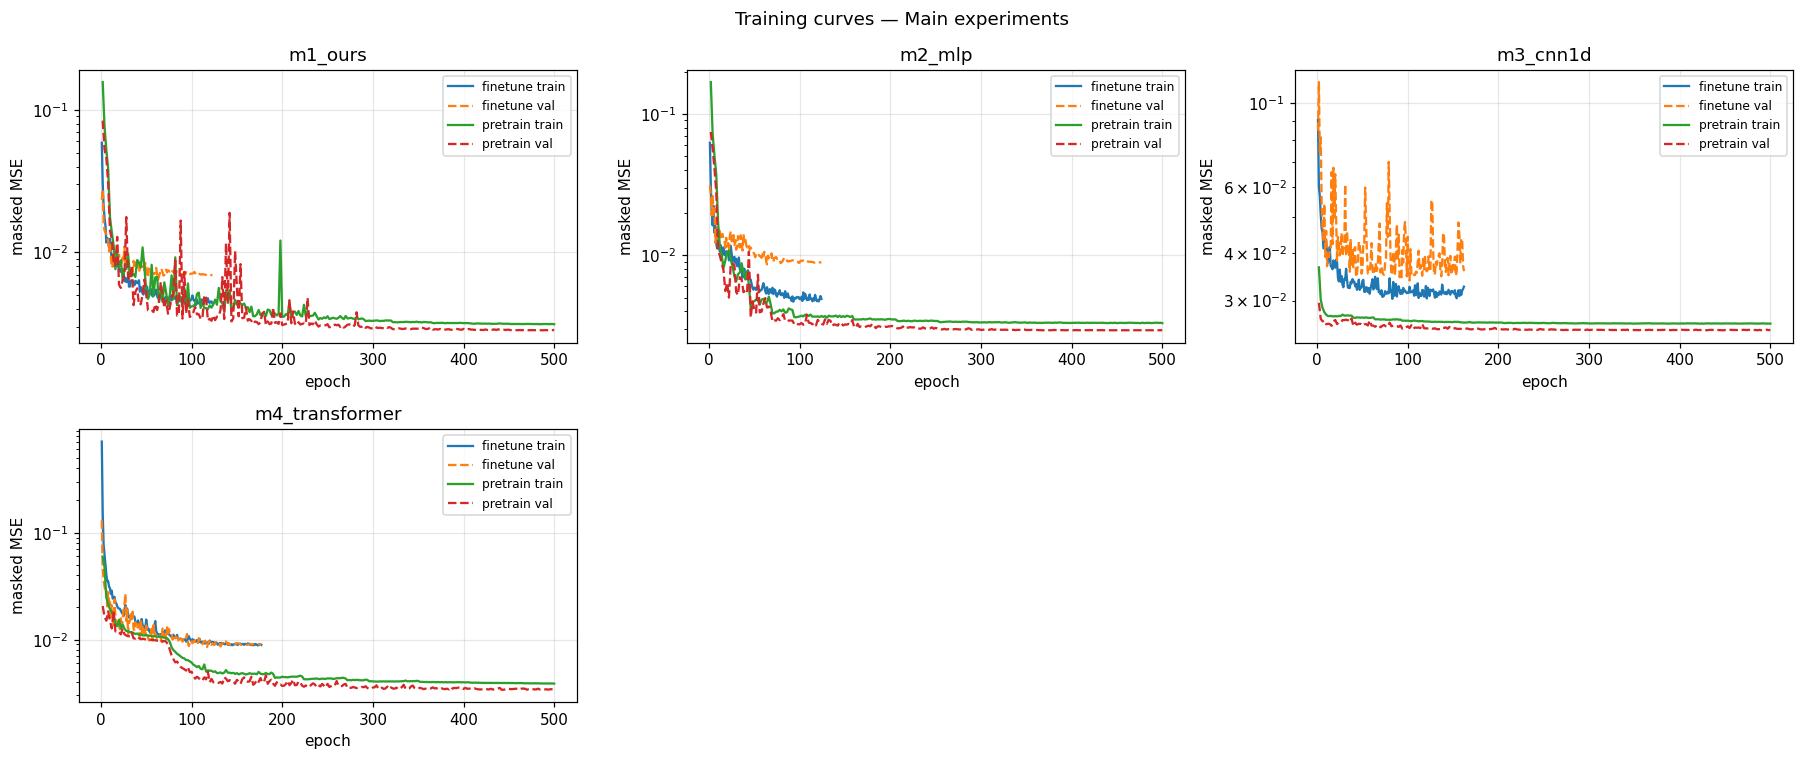

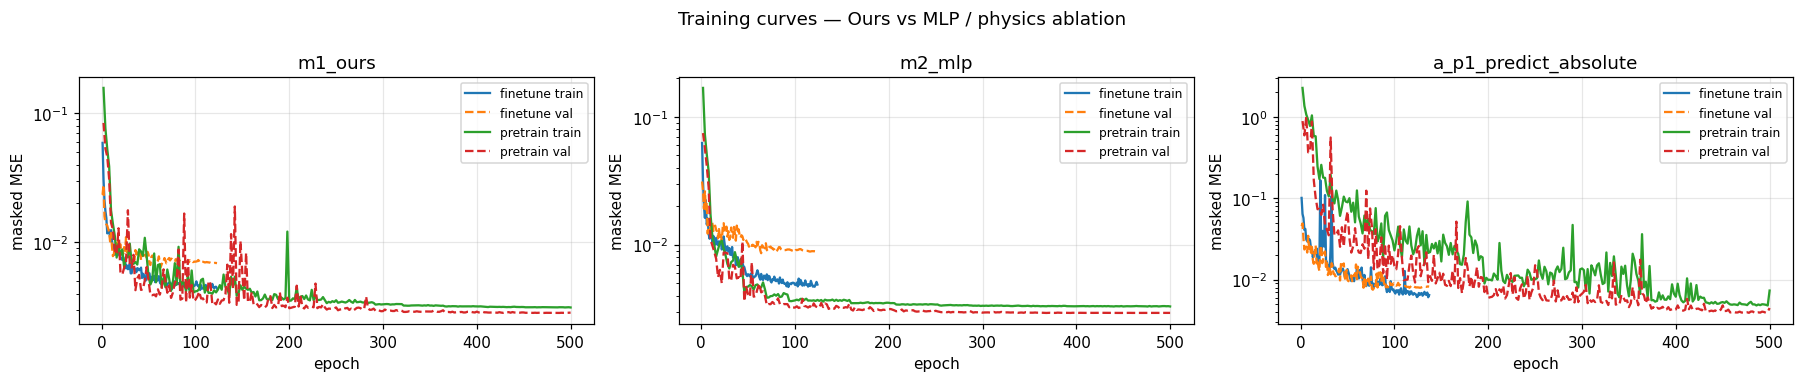

In [12]:
def _load_history(exp: str, seed: int = None) -> pd.DataFrame | None:
    s = seed if seed is not None else SEED
    p = seed_dir(s) / exp / "history.csv"
    if not p.exists():
        return None
    df = pd.read_csv(p)
    for col in ["train", "val", "lr"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def plot_training_curves(exps: list[str], title: str = "Training curves"):
    exps_with_data = [e for e in exps if _load_history(e) is not None]
    if not exps_with_data:
        print(f"No history.csv found for any of {exps}")
        return
    n = len(exps_with_data)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 3.5 * rows), squeeze=False)
    for i, exp in enumerate(exps_with_data):
        ax = axes[i // cols][i % cols]
        df = _load_history(exp)
        for stage, sub in df.groupby("stage"):
            sub = sub.sort_values("epoch")
            ax.plot(sub["epoch"], sub["train"], label=f"{stage} train", linestyle="-")
            ax.plot(sub["epoch"], sub["val"], label=f"{stage} val", linestyle="--")
        ax.set_title(exp)
        ax.set_xlabel("epoch")
        ax.set_ylabel("masked MSE")
        ax.set_yscale("log")
        ax.legend(fontsize=8)
    # Hide empty axes
    for j in range(len(exps_with_data), rows * cols):
        axes[j // cols][j % cols].axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_training_curves(MAIN, title="Training curves — Main experiments")
plot_training_curves(["m1_ours", "m2_mlp", "a_p1_predict_absolute"],
                     title="Training curves — Ours vs MLP / physics ablation")

## 2. Methods comparison — headline bars

MAE and Kaggle Score (both in dB) across the four main methods, broken down by Public / Private split.

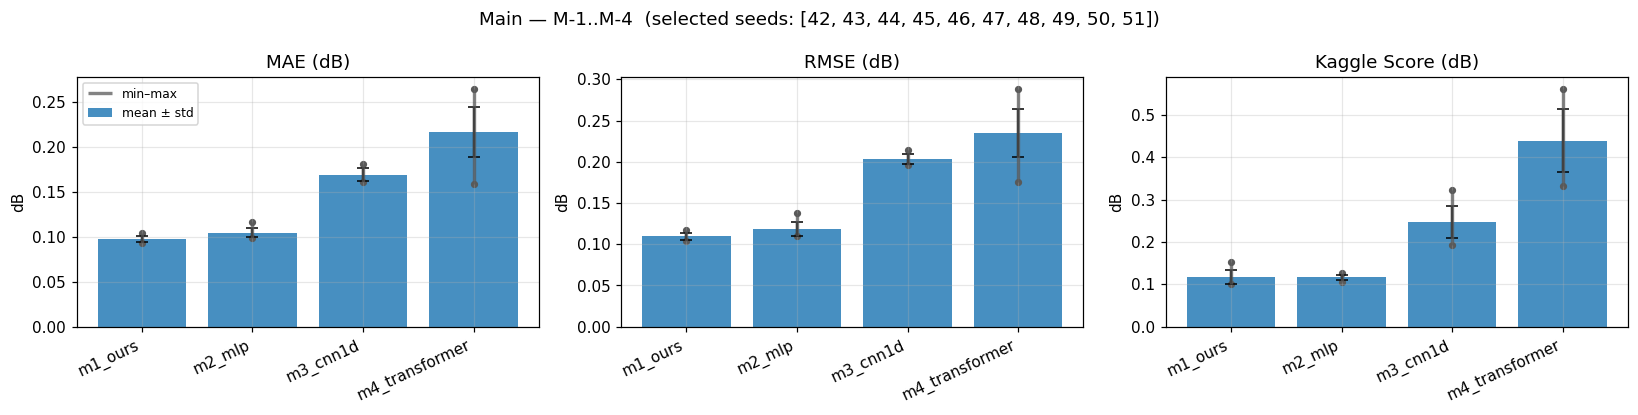

,n_seeds,seeds,MAE (dB) mean±std,MAE (dB) min–max,MAE (dB) range,RMSE (dB) mean±std,RMSE (dB) min–max,RMSE (dB) range,Kaggle Score (dB) mean±std,Kaggle Score (dB) min–max,Kaggle Score (dB) range
experiment,,,,,,,,,,,
m1_ours,10,"42,43,44,45,46,47,48,49,50,51",0.0972 ± 0.0035,0.0925–0.1035,0.011066,0.1096 ± 0.0044,0.1033–0.1177,0.014441,0.1165 ± 0.0166,0.1006–0.1531,0.052474
m2_mlp,10,"42,43,44,45,46,47,48,49,50,51",0.1042 ± 0.0049,0.0983–0.1159,0.017607,0.1185 ± 0.0081,0.1099–0.1379,0.027917,0.1162 ± 0.0061,0.1058–0.1258,0.020016
m3_cnn1d,10,"42,43,44,45,46,47,48,49,50,51",0.1690 ± 0.0068,0.1611–0.1808,0.019632,0.2029 ± 0.0060,0.1965–0.2137,0.017200,0.2465 ± 0.0384,0.1933–0.3223,0.129040
m4_transformer,10,"42,43,44,45,46,47,48,49,50,51",0.2162 ± 0.0281,0.1589–0.2645,0.105534,0.2346 ± 0.0292,0.1752–0.2887,0.113534,0.4391 ± 0.0751,0.3320–0.5619,0.229956


In [13]:
def _load_metrics(exp: str, seed: int = None) -> dict | None:
    s = seed if seed is not None else SEED
    p = seed_dir(s) / exp / "metrics.json"
    if not p.exists():
        return None
    return json.loads(p.read_text())


def _method_seed_rows(exps: list[str], seeds: list[int] | None = None) -> pd.DataFrame:
    """One row per (experiment, seed), restricted by SELECTED_SEEDS."""
    seeds = SELECTED_SEEDS if seeds is None else seeds
    rows = []
    for e in exps:
        for s in seeds:
            m = _load_metrics(e, seed=s)
            if m is None:
                continue
            ov = (m.get("evaluation") or {}).get("overall", {})
            byu = (m.get("evaluation") or {}).get("by_usage", {})
            rows.append({
                "experiment": e,
                "seed": s,
                "MAE (dB)": ov.get("MAE", np.nan),
                "RMSE (dB)": ov.get("RMSE", np.nan),
                "Kaggle Score (dB)": ov.get("KaggleScore", np.nan),
                "Public MAE (dB)": byu.get("Public", {}).get("MAE", np.nan),
                "Private MAE (dB)": byu.get("Private", {}).get("MAE", np.nan),
            })
    return pd.DataFrame(rows)


def _summarize_method_rows(long_df: pd.DataFrame) -> pd.DataFrame:
    metrics = ["MAE (dB)", "RMSE (dB)", "Kaggle Score (dB)", "Public MAE (dB)", "Private MAE (dB)"]
    rows = []
    for exp, sub in long_df.groupby("experiment", sort=False):
        row = {"experiment": exp, "n_seeds": sub["seed"].nunique(), "seeds": ",".join(map(str, sorted(sub["seed"].unique())))}
        for metric in metrics:
            vals = pd.to_numeric(sub[metric], errors="coerce")
            row[f"{metric} mean"] = vals.mean()
            row[f"{metric} std"] = vals.std(ddof=0)
            row[f"{metric} min"] = vals.min()
            row[f"{metric} max"] = vals.max()
            row[f"{metric} range"] = vals.max() - vals.min()
            row[f"{metric} mean±std"] = f"{vals.mean():.4f} ± {vals.std(ddof=0):.4f}"
            row[f"{metric} min–max"] = f"{vals.min():.4f}–{vals.max():.4f}"
        rows.append(row)
    return pd.DataFrame(rows).set_index("experiment")


def compare_methods(exps: list[str], title: str = "Method comparison"):
    """Cross-seed method comparison.

    Bars = mean across SELECTED_SEEDS, black error bars = std, grey vertical
    lines = min/max range.  The returned DataFrame includes mean/std/min/max.
    """
    long_df = _method_seed_rows(exps)
    if long_df.empty:
        print(f"No metrics found for {exps} under selected seeds {SELECTED_SEEDS}")
        return pd.DataFrame()

    df = _summarize_method_rows(long_df)
    plot_metrics = ["MAE (dB)", "RMSE (dB)", "Kaggle Score (dB)"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    x = np.arange(len(df.index))
    for ax, metric in zip(axes, plot_metrics):
        mean = df[f"{metric} mean"].values
        std = df[f"{metric} std"].values
        vmin = df[f"{metric} min"].values
        vmax = df[f"{metric} max"].values
        ax.bar(x, mean, yerr=std, capsize=4, alpha=0.82, label="mean ± std")
        # Overlay min-max range as a light grey line with caps.
        ax.vlines(x, vmin, vmax, colors="0.35", linewidth=2.2, alpha=0.75, label="min–max" if ax is axes[0] else None)
        ax.scatter(x, vmin, color="0.35", s=14)
        ax.scatter(x, vmax, color="0.35", s=14)
        ax.set_title(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(df.index, rotation=25, ha="right")
        ax.set_ylabel("dB")
        ax.grid(axis="y", alpha=0.3)
    axes[0].legend(fontsize=8)
    fig.suptitle(f"{title}  (selected seeds: {SELECTED_SEEDS})")
    fig.tight_layout()
    plt.show()

    # Compact paper-facing table.
    display_cols = ["n_seeds", "seeds"]
    for metric in ["MAE (dB)", "RMSE (dB)", "Kaggle Score (dB)"]:
        display_cols += [f"{metric} mean±std", f"{metric} min–max", f"{metric} range"]
    return df[display_cols]


df_main = compare_methods(MAIN, title="Main — M-1..M-4")
df_main

### 2.1 Ours vs MLP MAE gap

This is the key architectural comparison: same transfer protocol and same physics-grounded target parameterization, but FourierKAN (`m1_ours`) vs same-size MLP (`m2_mlp`).

We define:

```text
MAE gap = MAE_mlp - MAE_ours
```

So **positive gap means Ours is better** (lower MAE).

Ours vs MLP MAE gap (MLP - Ours; positive = Ours better)


,n_valid_seeds,seeds,gap_mean_dB,gap_std_dB,gap_min_dB,gap_max_dB,gap_range_dB,relative_gap_mean_pct,ours_win_rate
0,10,"42,43,44,45,46,47,48,49,50,51",0.006995,0.004824,-0.000353,0.013481,0.013834,6.569741,0.9


,seed,ours_MAE_dB,mlp_MAE_dB,gap_MLP_minus_Ours_dB,relative_gap_pct,ours_better,note
0,42,0.098943,0.106072,0.007129,6.721190,True,positive gap = Ours better
1,43,0.092451,0.099480,0.007028,7.064897,True,positive gap = Ours better
2,44,0.093602,0.107083,0.013481,12.589343,True,positive gap = Ours better
3,45,0.099183,0.098830,-0.000353,-0.356953,False,positive gap = Ours better
4,46,0.097496,0.098319,0.000823,0.837544,True,positive gap = Ours better
5,47,0.101097,0.102334,0.001237,1.208893,True,positive gap = Ours better
6,48,0.097951,0.105124,0.007173,6.823018,True,positive gap = Ours better
7,49,0.103517,0.115926,0.012409,10.704567,True,positive gap = Ours better
8,50,0.092893,0.105782,0.012889,12.184610,True,positive gap = Ours better
9,51,0.094572,0.102707,0.008135,7.920301,True,positive gap = Ours better


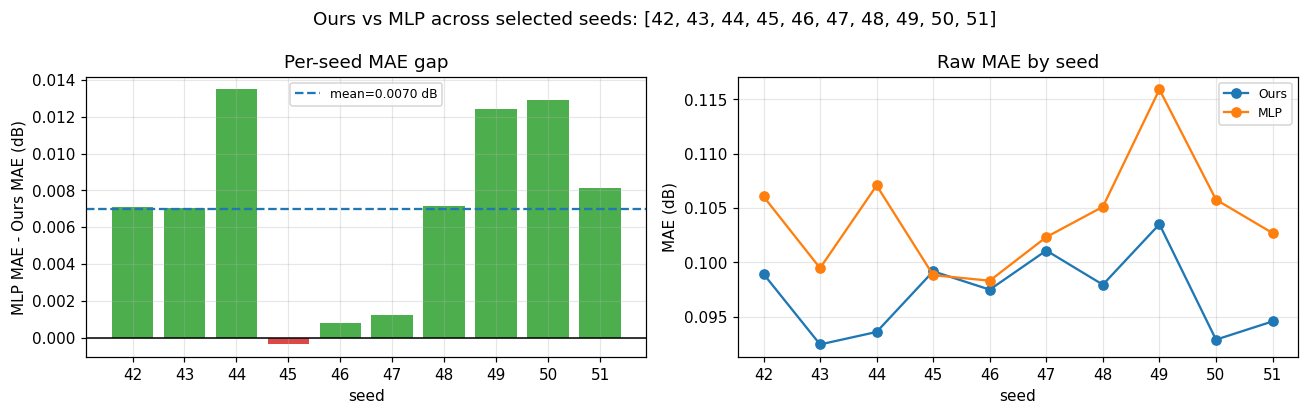

,seed,ours_MAE_dB,mlp_MAE_dB,gap_MLP_minus_Ours_dB,relative_gap_pct,ours_better,note
0,42,0.098943,0.106072,0.007129,6.721190,True,positive gap = Ours better
1,43,0.092451,0.099480,0.007028,7.064897,True,positive gap = Ours better
2,44,0.093602,0.107083,0.013481,12.589343,True,positive gap = Ours better
3,45,0.099183,0.098830,-0.000353,-0.356953,False,positive gap = Ours better
4,46,0.097496,0.098319,0.000823,0.837544,True,positive gap = Ours better
5,47,0.101097,0.102334,0.001237,1.208893,True,positive gap = Ours better
6,48,0.097951,0.105124,0.007173,6.823018,True,positive gap = Ours better
7,49,0.103517,0.115926,0.012409,10.704567,True,positive gap = Ours better
8,50,0.092893,0.105782,0.012889,12.184610,True,positive gap = Ours better
9,51,0.094572,0.102707,0.008135,7.920301,True,positive gap = Ours better


In [14]:
def ours_vs_mlp_gap(seeds: list[int] | None = None) -> pd.DataFrame:
    """Compute per-seed MAE gap: MLP - Ours.

    Positive values mean `m1_ours` has lower MAE than `m2_mlp`.
    Uses SELECTED_SEEDS by default.
    """
    seeds = SELECTED_SEEDS if seeds is None else seeds
    rows = []
    for s in seeds:
        ours = _load_metrics("m1_ours", seed=s)
        mlp = _load_metrics("m2_mlp", seed=s)
        if ours is None or mlp is None:
            rows.append({
                "seed": s,
                "ours_MAE_dB": np.nan,
                "mlp_MAE_dB": np.nan,
                "gap_MLP_minus_Ours_dB": np.nan,
                "relative_gap_pct": np.nan,
                "ours_better": np.nan,
                "note": "missing m1_ours or m2_mlp metrics",
            })
            continue
        ours_mae = (ours.get("evaluation") or {}).get("overall", {}).get("MAE", np.nan)
        mlp_mae = (mlp.get("evaluation") or {}).get("overall", {}).get("MAE", np.nan)
        gap = mlp_mae - ours_mae
        rel = 100.0 * gap / mlp_mae if pd.notna(mlp_mae) and mlp_mae != 0 else np.nan
        rows.append({
            "seed": s,
            "ours_MAE_dB": ours_mae,
            "mlp_MAE_dB": mlp_mae,
            "gap_MLP_minus_Ours_dB": gap,
            "relative_gap_pct": rel,
            "ours_better": bool(gap > 0) if pd.notna(gap) else np.nan,
            "note": "positive gap = Ours better",
        })
    df = pd.DataFrame(rows)

    valid = df.dropna(subset=["gap_MLP_minus_Ours_dB"])
    if valid.empty:
        print("No valid paired m1_ours/m2_mlp metrics for selected seeds:", seeds)
        return df

    gap = valid["gap_MLP_minus_Ours_dB"]
    rel = valid["relative_gap_pct"]
    summary = pd.DataFrame({
        "n_valid_seeds": [len(valid)],
        "seeds": [",".join(map(str, valid["seed"].astype(int).tolist()))],
        "gap_mean_dB": [gap.mean()],
        "gap_std_dB": [gap.std(ddof=0)],
        "gap_min_dB": [gap.min()],
        "gap_max_dB": [gap.max()],
        "gap_range_dB": [gap.max() - gap.min()],
        "relative_gap_mean_pct": [rel.mean()],
        "ours_win_rate": [valid["ours_better"].mean()],
    })

    print("Ours vs MLP MAE gap (MLP - Ours; positive = Ours better)")
    display(summary.round(6))
    display(df.round(6))

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    colors = ["tab:green" if x > 0 else "tab:red" for x in df["gap_MLP_minus_Ours_dB"].fillna(0)]
    axes[0].bar(df["seed"].astype(str), df["gap_MLP_minus_Ours_dB"], color=colors, alpha=0.85)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].axhline(gap.mean(), color="tab:blue", linestyle="--", label=f"mean={gap.mean():.4f} dB")
    axes[0].set_title("Per-seed MAE gap")
    axes[0].set_xlabel("seed")
    axes[0].set_ylabel("MLP MAE - Ours MAE (dB)")
    axes[0].legend(fontsize=8)
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].plot(valid["seed"].astype(str), valid["ours_MAE_dB"], marker="o", label="Ours")
    axes[1].plot(valid["seed"].astype(str), valid["mlp_MAE_dB"], marker="o", label="MLP")
    axes[1].set_title("Raw MAE by seed")
    axes[1].set_xlabel("seed")
    axes[1].set_ylabel("MAE (dB)")
    axes[1].legend(fontsize=8)
    axes[1].grid(axis="y", alpha=0.3)

    fig.suptitle(f"Ours vs MLP across selected seeds: {SELECTED_SEEDS}")
    fig.tight_layout()
    plt.show()
    return df


df_ours_mlp_gap = ours_vs_mlp_gap()
df_ours_mlp_gap

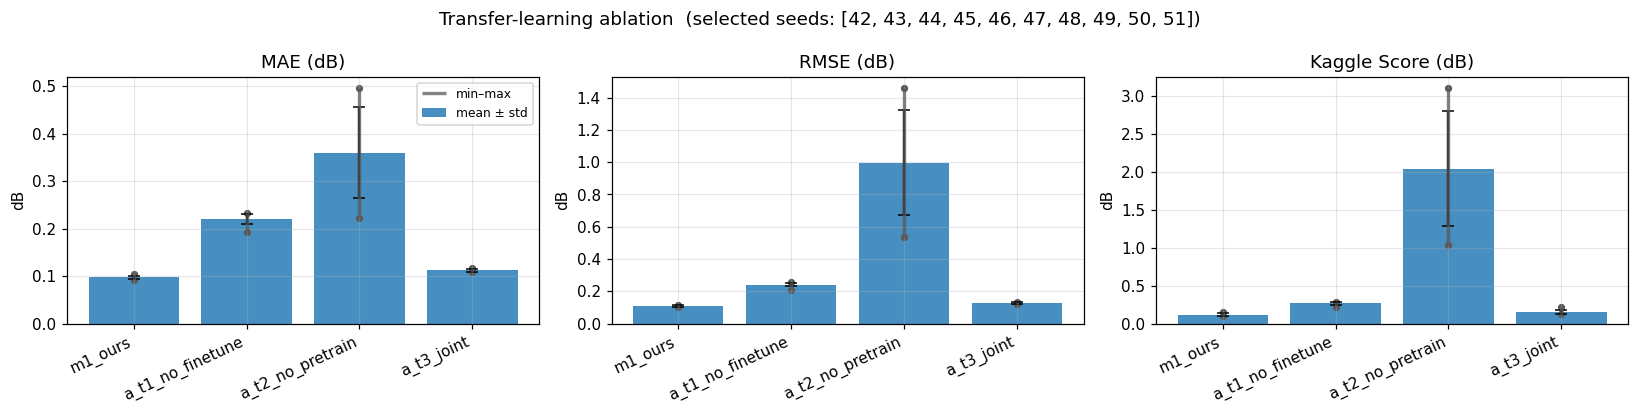

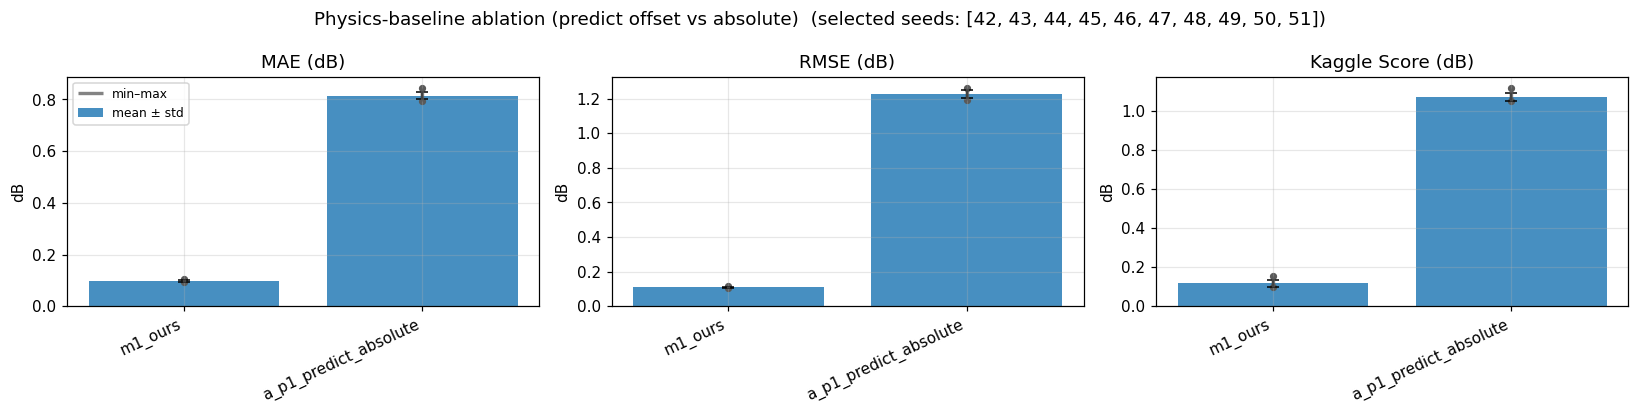

In [15]:
compare_methods(TRANSFER, title="Transfer-learning ablation")
compare_methods(PHYSICS, title="Physics-baseline ablation (predict offset vs absolute)")
pass

## 3. Category-stratified MAE (dB)

Per-`Category` (aging / shb / unseen / cosmos) and per-`EDFA_type` breakdowns, heat-map style.

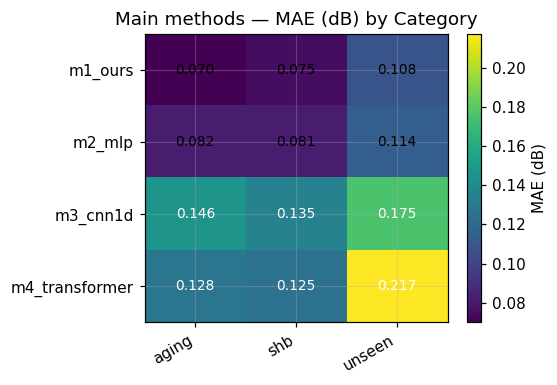

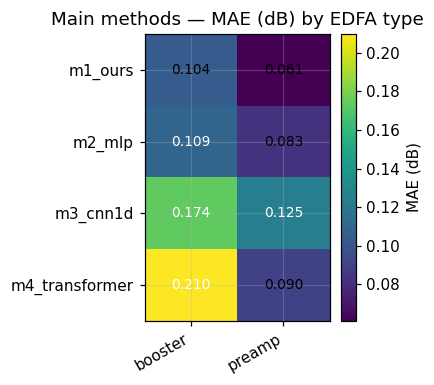

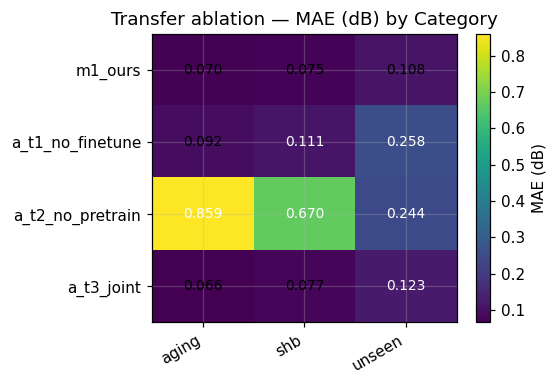

In [16]:
def stratified_heatmap(exps: list[str], key: str, title: str):
    """`key` is 'by_category' or 'by_edfa_type'."""
    rows = {}
    strata: set[str] = set()
    for e in exps:
        m = _load_metrics(e)
        if m is None:
            continue
        grp = (m.get("evaluation") or {}).get(key, {})
        rows[e] = {k: v.get("MAE", np.nan) for k, v in grp.items()}
        strata |= set(rows[e].keys())
    if not rows:
        print(f"No metrics for {exps}")
        return
    ordered_strata = sorted(strata)
    df = pd.DataFrame({e: [rows[e].get(s, np.nan) for s in ordered_strata]
                       for e in rows}, index=ordered_strata).T
    fig, ax = plt.subplots(figsize=(1.5 + 1.2 * len(ordered_strata), 0.6 * len(df) + 1.2))
    im = ax.imshow(df.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(ordered_strata)))
    ax.set_xticklabels(ordered_strata, rotation=30, ha="right")
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            v = df.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        color="white" if v > np.nanmedian(df.values) else "black", fontsize=9)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="MAE (dB)")
    fig.tight_layout()
    plt.show()
    return df


stratified_heatmap(MAIN, "by_category", "Main methods — MAE (dB) by Category")
stratified_heatmap(MAIN, "by_edfa_type", "Main methods — MAE (dB) by EDFA type")
stratified_heatmap(TRANSFER, "by_category", "Transfer ablation — MAE (dB) by Category")
pass

## 4. Per-channel error distribution

Box plot of `|y_pred − y_true|` across the 95 WDM channels, masked to activated channels only. Each method contributes one box per channel — here we summarise each channel's error distribution across all test rows.

/opt/miniconda3/envs/ofc_ml/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/opt/miniconda3/envs/ofc_ml/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


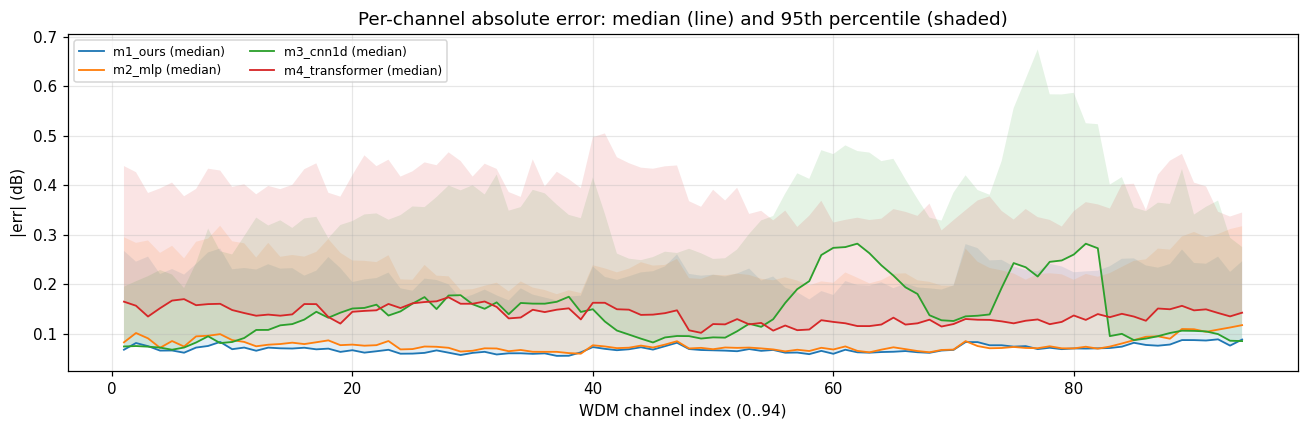

In [17]:
N_CHANNELS = 95
_mask_cols = sorted(
    [f"DUT_WSS_activated_channel_index_{i:02d}" for i in range(N_CHANNELS)],
    key=lambda x: int(x.split("_")[-1]),
)
_lbl_cols = [f"calculated_gain_spectra_{i:02d}" for i in range(N_CHANNELS)]


def _test_frames():
    test_features = pd.read_csv(DATA_DIR / "test_features.csv")
    test_labels = pd.read_csv(DATA_DIR / "test_labels.csv")
    return test_features, test_labels


def _per_channel_abs_err(exp: str, test_features: pd.DataFrame, test_labels: pd.DataFrame,
                         seed: int = None) -> np.ndarray | None:
    s = seed if seed is not None else SEED
    p = seed_dir(s) / exp / "submission.csv"
    if not p.exists():
        return None
    sub = pd.read_csv(p)
    # Align on ID
    merged_pred = test_features[["ID"]].merge(sub[["ID"] + _lbl_cols], on="ID", how="left")
    y_pred = merged_pred[_lbl_cols].values.astype(np.float32)
    merged_true = test_features[["ID"]].merge(test_labels[["ID"] + _lbl_cols], on="ID", how="left")
    y_true = merged_true[_lbl_cols].values.astype(np.float32)
    mask = test_features[_mask_cols].values.astype(np.float32)
    err = np.abs(y_pred - y_true)
    err[mask <= 0] = np.nan  # drop inactive channels
    return err


def plot_channel_error_medians(exps: list[str]):
    test_features, test_labels = _test_frames()
    fig, ax = plt.subplots(figsize=(12, 4))
    for e in exps:
        err = _per_channel_abs_err(e, test_features, test_labels)
        if err is None:
            continue
        med = np.nanmedian(err, axis=0)
        p95 = np.nanquantile(err, 0.95, axis=0)
        ax.plot(range(N_CHANNELS), med, label=f"{e} (median)", linewidth=1.2)
        ax.fill_between(range(N_CHANNELS), med, p95, alpha=0.12)
    ax.set_xlabel("WDM channel index (0..94)")
    ax.set_ylabel("|err| (dB)")
    ax.set_title("Per-channel absolute error: median (line) and 95th percentile (shaded)")
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    plt.show()


plot_channel_error_medians(MAIN)

## 5. Typical prediction spectra

Pick one sample per `Category` and overlay ground-truth vs predicted gain for the 4 main methods.

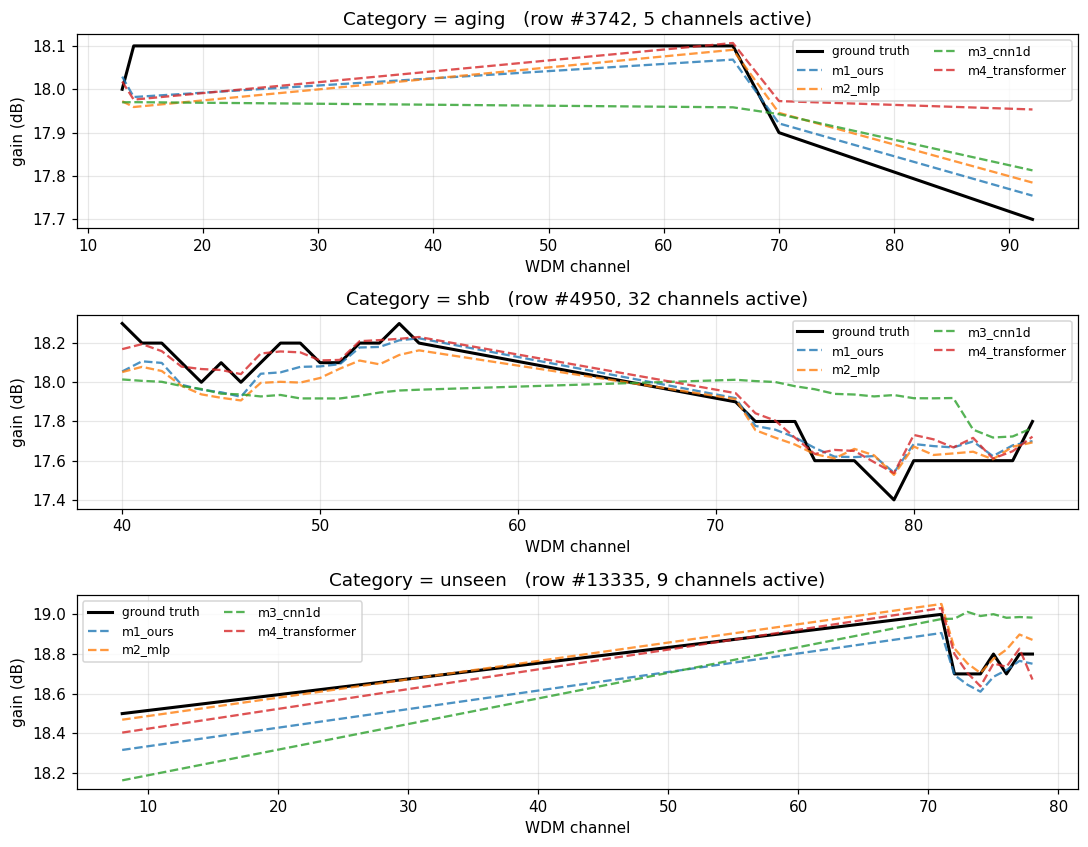

In [18]:
def plot_example_spectra(exps: list[str], seed: int = 0):
    test_features, test_labels = _test_frames()
    rng = np.random.default_rng(seed)

    categories = [c for c in ["aging", "shb", "unseen", "cosmos"] if c in test_features["Category"].unique()]
    fig, axes = plt.subplots(len(categories), 1, figsize=(10, 2.6 * len(categories)), squeeze=False)

    # Align everything on the test_features order once.
    merged_true = test_features[["ID", "Category"]].merge(test_labels[["ID"] + _lbl_cols], on="ID", how="left")
    y_true_all = merged_true[_lbl_cols].values
    mask_all = test_features[_mask_cols].values

    preds_by_exp = {}
    for e in exps:
        err = _per_channel_abs_err(e, test_features, test_labels)  # just to hit the file + align
        p = seed_dir(SEED) / e / "submission.csv"
        if not p.exists():
            continue
        sub = pd.read_csv(p)
        merged = test_features[["ID"]].merge(sub[["ID"] + _lbl_cols], on="ID", how="left")
        preds_by_exp[e] = merged[_lbl_cols].values

    for i, cat in enumerate(categories):
        idxs = merged_true.index[merged_true["Category"] == cat].tolist()
        if not idxs:
            continue
        pick = int(rng.choice(idxs))
        m = mask_all[pick].astype(bool)
        ax = axes[i][0]
        ax.plot(np.arange(N_CHANNELS)[m], y_true_all[pick][m], "k-", linewidth=2, label="ground truth")
        for e, preds in preds_by_exp.items():
            ax.plot(np.arange(N_CHANNELS)[m], preds[pick][m], linestyle="--", alpha=0.8, label=e)
        ax.set_title(f"Category = {cat}   (row #{pick}, {m.sum()} channels active)")
        ax.set_xlabel("WDM channel")
        ax.set_ylabel("gain (dB)")
        ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    plt.show()


plot_example_spectra(MAIN)

## 6. Aggregate tables at a glance

Pretty-print the auto-generated paper tables under `results/_tables/`.

In [19]:
from IPython.display import display

# Prefer the new multi-seed summary tables (`*_summary.csv`).  Fall back to the
# per-seed long tables if summaries are missing.
_candidates = [
    ("table1_main_summary.csv",        "table1_main_per_seed.csv"),
    ("table2_transfer_summary.csv",    "table2_transfer_per_seed.csv"),
    ("table3_physics_summary.csv",     "table3_physics_per_seed.csv"),
    ("figure3_data_scale_summary.csv", "figure3_data_scale_per_seed.csv"),
]
for primary, fallback in _candidates:
    df = load_selected_summary(primary, fallback)
    if df.empty:
        continue
    keep = [c for c in df.columns
            if c in ("experiment", "seed", "n_seeds", "seeds", "model", "stages",
                     "params", "cosmos_ratio", "kaggle_ratio", "predict_absolute",
                     "ratio", "axis")
            or c.endswith("_str")
            or (("_dB" in c) and not c.endswith(("_mean", "_std")))]
    print(f"=== {primary} (selected seeds: {SELECTED_SEEDS}) ===")
    display(df[keep])

=== table1_main_summary.csv (selected seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]) ===


,experiment,n_seeds,seeds,model,stages,params,predict_absolute,cosmos_ratio,kaggle_ratio,MAE_dB_str,...,aging_MAE_dB_str,shb_MAE_dB_str,unseen_MAE_dB_str,cosmos_MAE_dB_str,booster_MAE_dB_str,preamp_MAE_dB_str,pretrain_loss_str,finetune_loss_str,joint_loss_str,wall_time_sec_str
0,m1_ours,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,"pretrain,finetune",290399,False,1.0,1.0,0.0972 ± 0.0035,...,0.0720 ± 0.0024,0.0760 ± 0.0026,0.1053 ± 0.0045,,0.1020 ± 0.0041,0.0630 ± 0.0016,0.0029 ± 0.0000,0.0050 ± 0.0009,,80.8444 ± 17.2594
1,m2_mlp,10,"42,43,44,45,46,47,48,49,50,51",mlp,"pretrain,finetune",283231,False,1.0,1.0,0.1042 ± 0.0049,...,0.0733 ± 0.0046,0.0766 ± 0.0044,0.1143 ± 0.0062,,0.1095 ± 0.0055,0.0671 ± 0.0062,0.0029 ± 0.0000,0.0055 ± 0.0013,,954.5751 ± 32.3573
2,m3_cnn1d,10,"42,43,44,45,46,47,48,49,50,51",cnn1d,"pretrain,finetune",281057,False,1.0,1.0,0.1690 ± 0.0068,...,0.1456 ± 0.0052,0.1393 ± 0.0043,0.1771 ± 0.0077,,0.1754 ± 0.0076,0.1244 ± 0.0023,0.0252 ± 0.0002,0.0294 ± 0.0074,,832.1401 ± 78.1685
3,m4_transformer,10,"42,43,44,45,46,47,48,49,50,51",transformer,"pretrain,finetune",309985,False,1.0,1.0,0.2162 ± 0.0281,...,0.1187 ± 0.0128,0.1188 ± 0.0129,0.2487 ± 0.0348,,0.2362 ± 0.0322,0.0760 ± 0.0068,0.0035 ± 0.0001,0.0087 ± 0.0024,,1871.3345 ± 130.3748


=== table2_transfer_summary.csv (selected seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]) ===


,experiment,n_seeds,seeds,model,stages,params,predict_absolute,cosmos_ratio,kaggle_ratio,MAE_dB_str,...,aging_MAE_dB_str,shb_MAE_dB_str,unseen_MAE_dB_str,cosmos_MAE_dB_str,booster_MAE_dB_str,preamp_MAE_dB_str,pretrain_loss_str,finetune_loss_str,joint_loss_str,wall_time_sec_str
0,m1_ours,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,"pretrain,finetune",290399,False,1.0,1.0,0.0972 ± 0.0035,...,0.0720 ± 0.0024,0.0760 ± 0.0026,0.1053 ± 0.0045,,0.1020 ± 0.0041,0.0630 ± 0.0016,0.0029 ± 0.0000,0.0050 ± 0.0009,,80.8444 ± 17.2594
1,a_t1_no_finetune,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,pretrain,290399,False,1.0,1.0,0.2201 ± 0.0104,...,0.0948 ± 0.0036,0.1056 ± 0.0041,0.2613 ± 0.0143,,0.2424 ± 0.0119,0.0644 ± 0.0010,0.0029 ± 0.0000,,,1251.2784 ± 22.6182
2,a_t2_no_pretrain,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,finetune,290399,False,1.0,1.0,0.3595 ± 0.0957,...,0.7994 ± 0.2685,0.6305 ± 0.2240,0.2221 ± 0.0417,,0.2129 ± 0.0423,1.3853 ± 0.4751,,0.0213 ± 0.0075,,144.8365 ± 35.1247
3,a_t3_joint,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,joint,290399,False,1.0,1.0,0.1122 ± 0.0026,...,0.0694 ± 0.0014,0.0796 ± 0.0047,0.1259 ± 0.0033,,0.1193 ± 0.0030,0.0625 ± 0.0014,,,0.0029 ± 0.0000,1242.8939 ± 51.3581


=== table3_physics_summary.csv (selected seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]) ===


,experiment,n_seeds,seeds,model,stages,params,predict_absolute,cosmos_ratio,kaggle_ratio,MAE_dB_str,...,aging_MAE_dB_str,shb_MAE_dB_str,unseen_MAE_dB_str,cosmos_MAE_dB_str,booster_MAE_dB_str,preamp_MAE_dB_str,pretrain_loss_str,finetune_loss_str,joint_loss_str,wall_time_sec_str
0,m1_ours,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,"pretrain,finetune",290399,False,1.0,1.0,0.0972 ± 0.0035,...,0.0720 ± 0.0024,0.0760 ± 0.0026,0.1053 ± 0.0045,,0.1020 ± 0.0041,0.0630 ± 0.0016,0.0029 ± 0.0000,0.0050 ± 0.0009,,80.8444 ± 17.2594
1,a_p1_predict_absolute,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,"pretrain,finetune",290399,True,1.0,1.0,0.8149 ± 0.0136,...,0.0772 ± 0.0063,0.0844 ± 0.0095,1.0603 ± 0.0167,,0.9218 ± 0.0150,0.0660 ± 0.0049,0.0037 ± 0.0002,0.0063 ± 0.0014,,1329.6986 ± 55.1609


## 7. Cross-seed mean ± std (selected seeds)

Uses `results/_tables/*_summary.csv` (produced by `python scripts/aggregate_results.py`).
Bars show the mean, error bars show std across seeds.

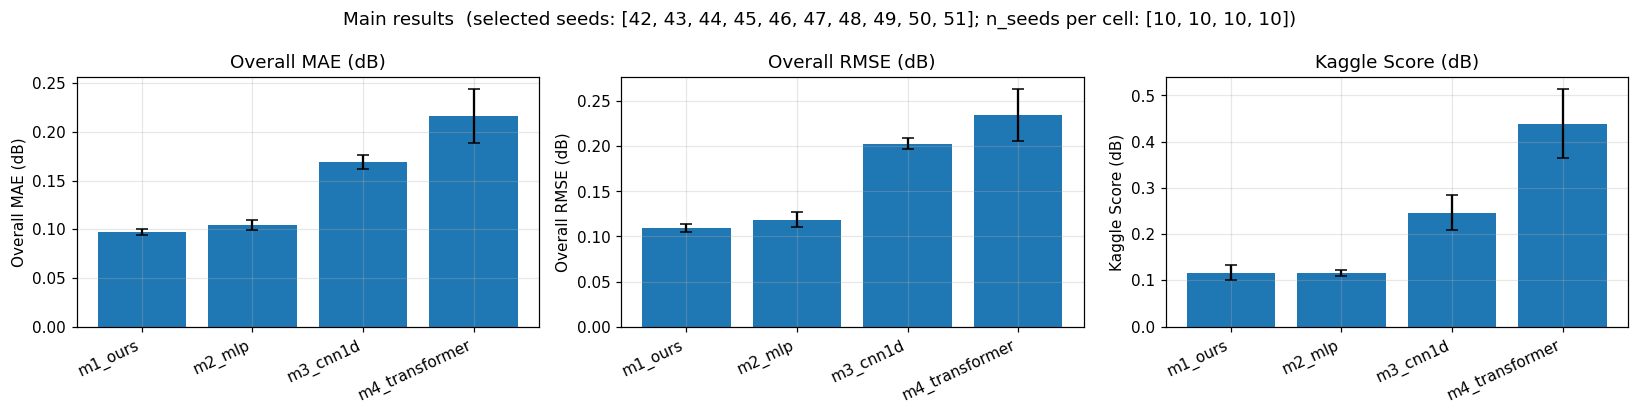

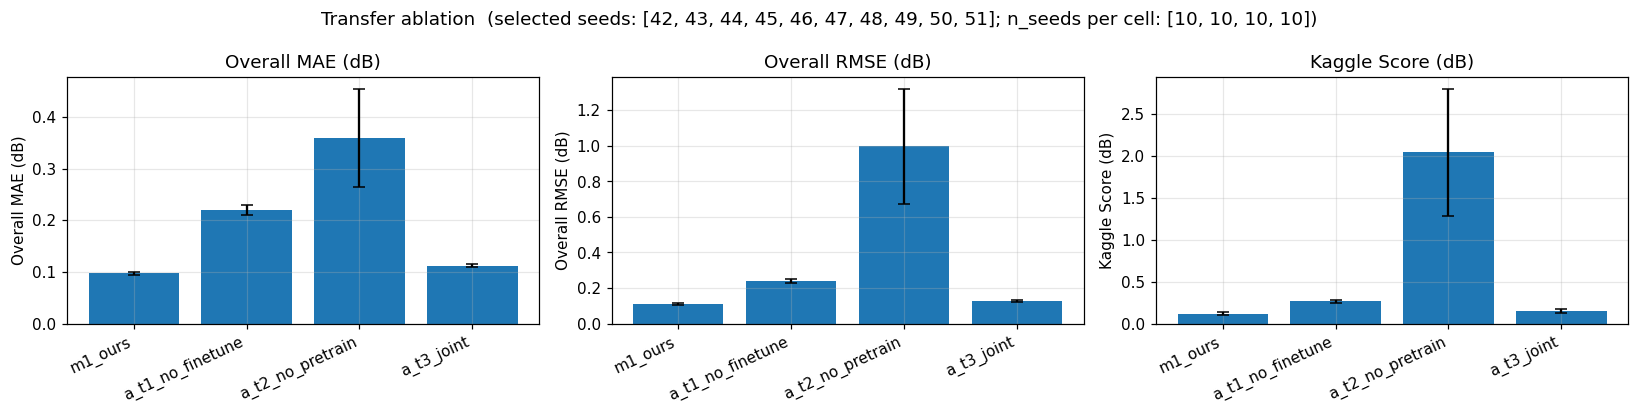

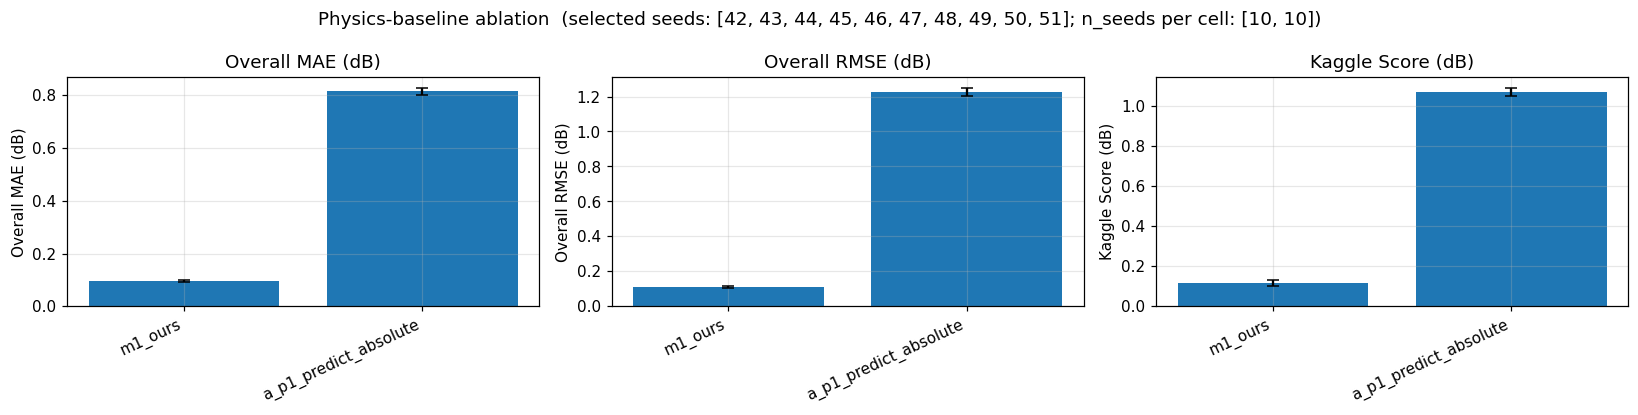

,experiment,n_seeds,seeds,model,stages,params,predict_absolute,cosmos_ratio,kaggle_ratio,MAE_dB_mean,...,pretrain_loss_str,finetune_loss_mean,finetune_loss_std,finetune_loss_str,joint_loss_mean,joint_loss_std,joint_loss_str,wall_time_sec_mean,wall_time_sec_std,wall_time_sec_str
0,m1_ours,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,"pretrain,finetune",290399,False,1.0,1.0,0.097171,...,0.0029 ± 0.0000,0.005025,0.000930,0.0050 ± 0.0009,NaN,NaN,,80.844412,17.259355,80.8444 ± 17.2594
1,a_p1_predict_absolute,10,"42,43,44,45,46,47,48,49,50,51",hybrid_fno_kan,"pretrain,finetune",290399,True,1.0,1.0,0.814862,...,0.0037 ± 0.0002,0.006346,0.001434,0.0063 ± 0.0014,NaN,NaN,,1329.698616,55.160911,1329.6986 ± 55.1609


In [20]:
def plot_cross_seed(summary_csv: str, title: str):
    df = load_selected_summary(summary_csv)
    if df.empty:
        print(f"[skip] {summary_csv} missing or has 0 rows after seed filter {SELECTED_SEEDS}.")
        return None
    metrics = [("MAE_dB", "Overall MAE (dB)"),
               ("RMSE_dB", "Overall RMSE (dB)"),
               ("KaggleScore_dB", "Kaggle Score (dB)")]
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 3.8))
    x = np.arange(len(df))
    for ax, (m, label) in zip(axes, metrics):
        mean_col, std_col = f"{m}_mean", f"{m}_std"
        if mean_col not in df or std_col not in df:
            continue
        ax.bar(x, df[mean_col], yerr=df[std_col], capsize=4)
        ax.set_xticks(x)
        ax.set_xticklabels(df["experiment"], rotation=25, ha="right")
        ax.set_ylabel(label)
        ax.set_title(label)
    n_seeds_str = df["n_seeds"].astype(int).tolist() if "n_seeds" in df else []
    fig.suptitle(f"{title}  (selected seeds: {SELECTED_SEEDS}; n_seeds per cell: {n_seeds_str})")
    fig.tight_layout()
    plt.show()
    return df


plot_cross_seed("table1_main_summary.csv",     "Main results")
plot_cross_seed("table2_transfer_summary.csv", "Transfer ablation")
plot_cross_seed("table3_physics_summary.csv",  "Physics-baseline ablation")

## 8. Training curves overlaid across seeds (stability check)

For a chosen experiment, overlay the per-epoch train / val loss from every seed available. Flat convergence across seeds = stable optimisation; wild divergence = unstable.

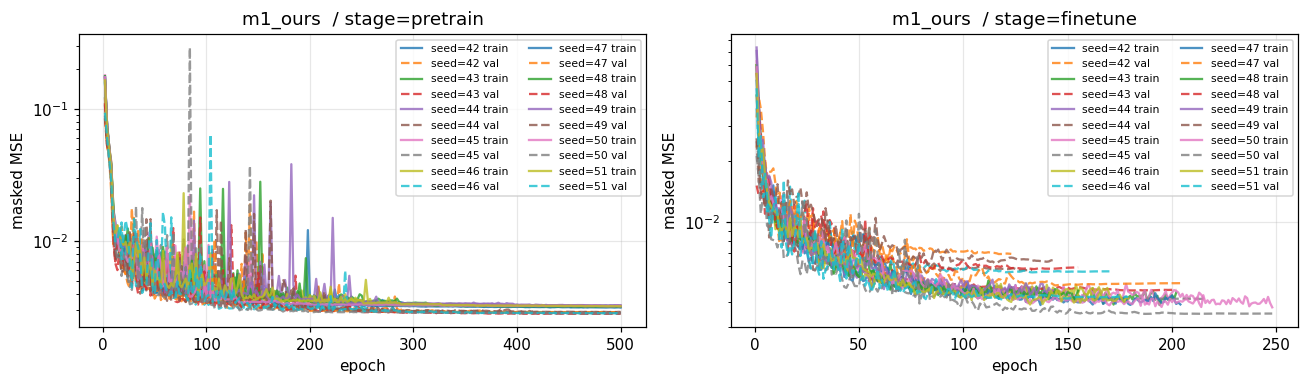

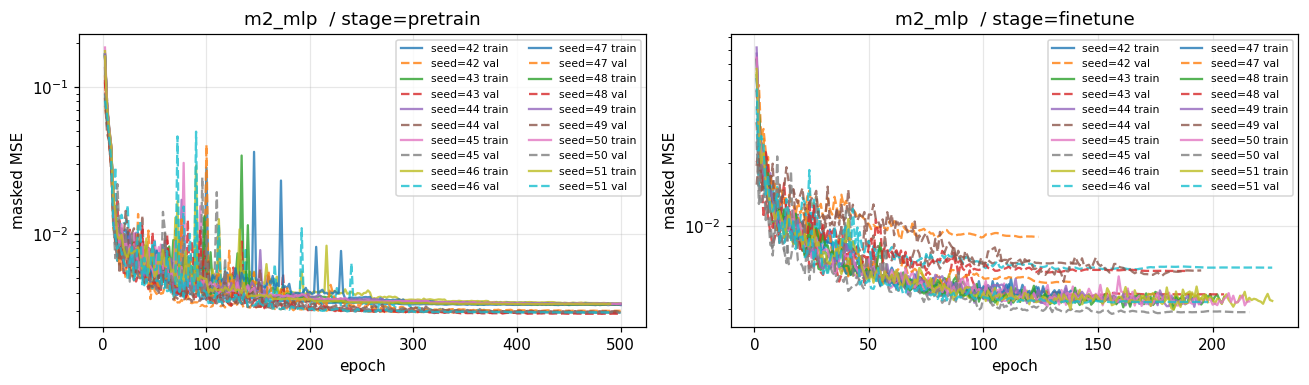

In [21]:
def plot_curves_across_seeds(exp: str, stages: tuple[str, ...] = ("pretrain", "finetune")):
    if not SELECTED_SEEDS:
        print("No selected seeds discovered. Check INCLUDE_SEEDS / results/seed_<N>."); return
    fig, axes = plt.subplots(1, len(stages), figsize=(6 * len(stages), 3.6), squeeze=False)
    any_plotted = False
    for ax, stage in zip(axes[0], stages):
        for seed in SELECTED_SEEDS:
            h = _load_history(exp, seed=seed)
            if h is None:
                continue
            sub = h[h["stage"] == stage].sort_values("epoch")
            if sub.empty:
                continue
            ax.plot(sub["epoch"], sub["train"], label=f"seed={seed} train", alpha=0.8)
            ax.plot(sub["epoch"], sub["val"],   label=f"seed={seed} val",   linestyle="--", alpha=0.8)
            any_plotted = True
        ax.set_title(f"{exp}  / stage={stage}")
        ax.set_xlabel("epoch")
        ax.set_ylabel("masked MSE")
        ax.set_yscale("log")
        ax.legend(fontsize=7, ncol=2)
    if not any_plotted:
        print(f"[skip] no history found for {exp}")
    fig.tight_layout()
    plt.show()


plot_curves_across_seeds("m1_ours")
plot_curves_across_seeds("m2_mlp")